# Ride Demand Forecasting - Data Prep Engine
Full preprocessing & feature engineering pipeline for ride-hailing data.

## 1. Data Understanding & Loading

In [1]:
import pandas as pd
import numpy as np
import json
import sqlite3
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
from scipy import stats
import matplotlib.pyplot as plt

# Load riders.csv
riders = pd.read_csv('riders.csv')

# Load trips.json
with open('trips.json') as f:
    trips = pd.DataFrame(json.load(f))

# Load city_zones from SQL db
conn = sqlite3.connect('city_zones.db')
zones = pd.read_sql_query("SELECT * FROM city_zones", conn)
conn.close()

print("RIDERS shape:", riders.shape)
print(riders.head())
print()
print("TRIPS shape:", trips.shape)
print(trips.head())
print()
print("ZONES shape:", zones.shape)
print(zones.head())

RIDERS shape: (300, 9)
  rider_id         name  age  gender       city signup_date  total_rides  \
0    R0001    Aarav Das   23    Male       Pune  2020-06-29           56   
1    R0002  Ishaan Nair   39  Female     Mumbai  2019-11-23           70   
2    R0003  Kavya Reddy   34    Male       Pune  2023-05-04           45   
3    R0004   Aarav Nair   19   Other    Kolkata  2019-07-28          464   
4    R0005   Diya Reddy   27    Male  Ahmedabad  2021-05-31          294   

   cancelled_rides  avg_rating  
0                0        3.76  
1                5        4.12  
2                9        3.76  
3                5        3.19  
4               30        3.53  

TRIPS shape: (2000, 9)
  trip_id rider_id     zone  distance_km  duration_min  fare_amount  \
0  T00001    R0037  Zone_10        11.83         74.59       104.88   
1  T00002    R0104   Zone_9         3.86         35.59        40.48   
2  T00003    R0045   Zone_8         4.70         31.03        46.39   
3  T00004    R

In [2]:
print("=== riders.info() ===")
riders.info()
print("\n=== trips.info() ===")
trips.info()
print("\n=== zones.info() ===")
zones.info()

=== riders.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rider_id         300 non-null    str    
 1   name             300 non-null    str    
 2   age              300 non-null    int64  
 3   gender           300 non-null    str    
 4   city             300 non-null    str    
 5   signup_date      300 non-null    str    
 6   total_rides      300 non-null    int64  
 7   cancelled_rides  300 non-null    int64  
 8   avg_rating       300 non-null    float64
dtypes: float64(1), int64(3), str(5)
memory usage: 21.2 KB

=== trips.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   trip_id       2000 non-null   str    
 1   rider_id      2000 non-null   str    
 2   zone          2000 non-nul

In [3]:
print("Missing values - riders:\n", riders.isna().sum())
print("\nMissing values - trips:\n", trips.isna().sum())
print("\nMissing values - zones:\n", zones.isna().sum())

Missing values - riders:
 rider_id           0
name               0
age                0
gender             0
city               0
signup_date        0
total_rides        0
cancelled_rides    0
avg_rating         0
dtype: int64

Missing values - trips:
 trip_id         0
rider_id        0
zone            0
distance_km     0
duration_min    0
fare_amount     0
payment_mode    0
ride_date       0
surge_flag      0
dtype: int64

Missing values - zones:
 zone_name             0
population_density    0
traffic_index         0
avg_speed_kmph        0
zone_type             0
dtype: int64


In [4]:
# Duplicates
print("Duplicate rows - riders:", riders.duplicated().sum())
print("Duplicate rows - trips:", trips.duplicated().sum())
print("Duplicate rows - zones:", zones.duplicated().sum())

Duplicate rows - riders: 0
Duplicate rows - trips: 0
Duplicate rows - zones: 0


In [5]:
# Invalid entries check
print("Riders with age < 10:", (riders['age'] < 10).sum())
print("Trips with negative distance:", (trips['distance_km'] < 0).sum())
print("Trips with negative fare:", (trips['fare_amount'] < 0).sum())
print("Trips with zero distance but fare > 0:", ((trips['distance_km'] == 0) & (trips['fare_amount'] > 0)).sum())

Riders with age < 10: 0
Trips with negative distance: 0
Trips with negative fare: 0
Trips with zero distance but fare > 0: 0


## 2. Data Cleaning

In [6]:
rows_before = len(trips)
missing_before = trips.isna().sum().sum() + riders.isna().sum().sum()

# Numeric missing values -> mean imputation (demonstrated even if none are missing)
num_cols = ['distance_km', 'duration_min', 'fare_amount']
num_imputer = SimpleImputer(strategy='mean')
trips[num_cols] = num_imputer.fit_transform(trips[num_cols])

# Categorical missing values -> most frequent
cat_cols = ['payment_mode', 'zone']
cat_imputer = SimpleImputer(strategy='most_frequent')
trips[cat_cols] = cat_imputer.fit_transform(trips[cat_cols])

# KNN Imputer for multivariate columns (trip duration, distance, fare amount)
knn_imputer = KNNImputer(n_neighbors=5)
trips[num_cols] = knn_imputer.fit_transform(trips[num_cols])

# Fix date formats -> consistent datetime
trips['ride_date'] = pd.to_datetime(trips['ride_date'], errors='coerce')
riders['signup_date'] = pd.to_datetime(riders['signup_date'], errors='coerce')

# Remove unrealistic entries
trips = trips[trips['fare_amount'] >= 0]
trips = trips[~((trips['distance_km'] == 0) & (trips['fare_amount'] > 0))]

print("Rows before cleaning:", rows_before, "-> after:", len(trips))

Rows before cleaning: 2000 -> after: 2000


## 3. Outlier Handling

In [7]:
rows_before_outliers = len(trips)

# Z-score method for fare & distance anomalies
z_fare = np.abs(stats.zscore(trips['fare_amount']))
z_dist = np.abs(stats.zscore(trips['distance_km']))
trips_outliers_z = trips[(z_fare > 3) | (z_dist > 3)]
print("Z-score outliers (fare/distance):", len(trips_outliers_z))

# IQR method for ride duration anomalies
Q1 = trips['duration_min'].quantile(0.25)
Q3 = trips['duration_min'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
duration_outliers = trips[(trips['duration_min'] < lower) | (trips['duration_min'] > upper)]
print("IQR outliers (duration):", len(duration_outliers))

# Before stats
print("\nBefore Winsorization - fare_amount stats:")
print(trips['fare_amount'].describe())

# Winsorize extreme surge fares (cap at 1st/99th percentile)
lower_cap = trips['fare_amount'].quantile(0.01)
upper_cap = trips['fare_amount'].quantile(0.99)
trips['fare_amount'] = trips['fare_amount'].clip(lower_cap, upper_cap)

print("\nAfter Winsorization - fare_amount stats:")
print(trips['fare_amount'].describe())

print("\nRows before outlier handling:", rows_before_outliers, "-> after:", len(trips))

Z-score outliers (fare/distance): 19
IQR outliers (duration): 18

Before Winsorization - fare_amount stats:
count    2000.000000
mean      134.600375
std        85.521989
min         0.250000
25%        70.440000
50%       121.850000
75%       182.867500
max       472.290000
Name: fare_amount, dtype: float64

After Winsorization - fare_amount stats:
count    2000.000000
mean      134.225530
std        84.222681
min         3.267400
25%        70.440000
50%       121.850000
75%       182.867500
max       379.682600
Name: fare_amount, dtype: float64

Rows before outlier handling: 2000 -> after: 2000


## 4. Data Transformation

In [8]:
# datetime -> hour, day_of_week, month
trips['hour'] = trips['ride_date'].dt.hour.fillna(0).astype(int)  # no time component in data, defaults to 0
trips['day_of_week'] = trips['ride_date'].dt.day_name()
trips['month'] = trips['ride_date'].dt.month

print(trips[['ride_date', 'hour', 'day_of_week', 'month']].head())

   ride_date  hour day_of_week  month
0 2023-11-13     0      Monday     11
1 2023-07-28     0      Friday      7
2 2024-01-14     0      Sunday      1
3 2023-12-13     0   Wednesday     12
4 2023-03-15     0   Wednesday      3


In [9]:
# Encoding
# Label Encode gender
le = LabelEncoder()
riders['gender_encoded'] = le.fit_transform(riders['gender'])

# keep original zone name before one-hot encoding (needed later to merge zone attributes)
trips['zone_name'] = trips['zone']

# One-Hot Encode payment_mode and zone
trips = pd.get_dummies(trips, columns=['payment_mode'], prefix='payment')
trips = pd.get_dummies(trips, columns=['zone'], prefix='zone')

# Ordinal Encode traffic_level (derived from zones' traffic_index -> Low/Medium/High)
zones['traffic_level'] = pd.qcut(zones['traffic_index'], q=3, labels=['Low', 'Medium', 'High'])
ordinal_enc = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
zones['traffic_level_encoded'] = ordinal_enc.fit_transform(zones[['traffic_level']])

print(riders[['gender', 'gender_encoded']].head())
print(zones[['zone_name', 'traffic_index', 'traffic_level', 'traffic_level_encoded']])

   gender  gender_encoded
0    Male               1
1  Female               0
2    Male               1
3   Other               2
4    Male               1
  zone_name  traffic_index traffic_level  traffic_level_encoded
0    Zone_1           2.43          High                    2.0
1    Zone_2           0.91           Low                    0.0
2    Zone_3           2.11          High                    2.0
3    Zone_4           2.46          High                    2.0
4    Zone_5           1.31           Low                    0.0
5    Zone_6           0.54           Low                    0.0
6    Zone_7           0.64           Low                    0.0
7    Zone_8           1.93        Medium                    1.0
8    Zone_9           1.83        Medium                    1.0
9   Zone_10           1.54        Medium                    1.0


In [10]:
# Binning customer ride frequency (Low/Med/High)
riders['ride_frequency_bin'] = pd.qcut(riders['total_rides'], q=3, labels=['Low', 'Medium', 'High'])
print(riders[['total_rides', 'ride_frequency_bin']].head())

   total_rides ride_frequency_bin
0           56                Low
1           70                Low
2           45                Low
3          464               High
4          294             Medium


In [11]:
# Transform skewed numeric columns
trips['fare_amount_log'] = np.log1p(trips['fare_amount'])
trips['distance_km_log'] = np.log1p(trips['distance_km'])
trips['duration_min_sqrt'] = np.sqrt(trips['duration_min'])

print(trips[['fare_amount', 'fare_amount_log', 'distance_km', 'distance_km_log', 'duration_min', 'duration_min_sqrt']].head())

   fare_amount  fare_amount_log  distance_km  distance_km_log  duration_min  \
0       104.88         4.662306        11.83         2.551786         74.59   
1        40.48         3.725211         3.86         1.581038         35.59   
2        46.39         3.858411         4.70         1.740466         31.03   
3       257.64         5.555437        11.06         2.489894         59.48   
4        72.74         4.300545         7.28         2.113843         67.59   

   duration_min_sqrt  
0           8.636550  
1           5.965735  
2           5.570458  
3           7.712328  
4           8.221314  


## 5. Feature Scaling

In [12]:
scale_cols = ['fare_amount', 'distance_km', 'duration_min']

print("BEFORE scaling:")
print(trips[scale_cols].agg(['mean', 'std', 'min', 'max']))

# StandardScaler
standard_scaler = StandardScaler()
trips_standard = pd.DataFrame(standard_scaler.fit_transform(trips[scale_cols]),
                               columns=[c + '_standard' for c in scale_cols], index=trips.index)

# MinMaxScaler
minmax_scaler = MinMaxScaler()
trips_minmax = pd.DataFrame(minmax_scaler.fit_transform(trips[scale_cols]),
                             columns=[c + '_minmax' for c in scale_cols], index=trips.index)

trips = pd.concat([trips, trips_standard, trips_minmax], axis=1)

print("\nAFTER StandardScaler:")
print(trips_standard.agg(['mean', 'std', 'min', 'max']))
print("\nAFTER MinMaxScaler:")
print(trips_minmax.agg(['mean', 'std', 'min', 'max']))

BEFORE scaling:
      fare_amount  distance_km  duration_min
mean   134.225530     8.247420     61.883410
std     84.222681     4.450904     35.980603
min      3.267400     0.020000      0.190000
max    379.682600    25.860000    201.070000

AFTER StandardScaler:
      fare_amount_standard  distance_km_standard  duration_min_standard
mean          8.881784e-17          5.329071e-18          -1.172396e-16
std           1.000250e+00          1.000250e+00           1.000250e+00
min          -1.555292e+00         -1.848945e+00          -1.715058e+00
max           2.915111e+00          3.958069e+00           3.869346e+00

AFTER MinMaxScaler:
      fare_amount_minmax  distance_km_minmax  duration_min_minmax
mean            0.347909            0.318399             0.307116
std             0.223749            0.172249             0.179115
min             0.000000            0.000000             0.000000
max             1.000000            1.000000             1.000000


## 6. Feature Construction

In [13]:
# Rider-level aggregates from trips
rider_agg = trips.groupby('rider_id').agg(
    total_distance=('distance_km', 'sum'),
    total_fare=('fare_amount', 'sum'),
    trip_count=('trip_id', 'count')
).reset_index()

rider_agg['avg_ride_distance'] = rider_agg['total_distance'] / rider_agg['trip_count']
rider_agg['avg_ride_fare'] = rider_agg['total_fare'] / rider_agg['trip_count']

riders = riders.merge(rider_agg[['rider_id', 'avg_ride_distance', 'avg_ride_fare']], on='rider_id', how='left')

# is_peak_hour: 1 if hour in [7-9, 18-21] else 0
trips['is_peak_hour'] = trips['hour'].apply(lambda h: 1 if (7 <= h <= 9 or 18 <= h <= 21) else 0)

# days_since_signup
riders['days_since_signup'] = (pd.Timestamp.today() - riders['signup_date']).dt.days

# ride_cancellation_rate
riders['ride_cancellation_rate'] = riders['cancelled_rides'] / riders['total_rides']

# surge_flag already exists in trips.json - verify logic (fare/distance > threshold)
threshold = (trips['fare_amount'] / trips['distance_km']).quantile(0.75)
trips['surge_flag_check'] = ((trips['fare_amount'] / trips['distance_km']) > threshold).astype(int)

print(riders[['rider_id', 'avg_ride_distance', 'avg_ride_fare', 'days_since_signup', 'ride_cancellation_rate']].head())
print(trips[['trip_id', 'is_peak_hour', 'surge_flag', 'surge_flag_check']].head())

  rider_id  avg_ride_distance  avg_ride_fare  days_since_signup  \
0    R0001          10.420000     158.785000               2267   
1    R0002          10.812857     167.944286               2486   
2    R0003           6.768000      97.171000               1228   
3    R0004           6.201667     113.838333               2604   
4    R0005           7.322857     132.350000               1931   

   ride_cancellation_rate  
0                0.000000  
1                0.071429  
2                0.200000  
3                0.010776  
4                0.102041  
  trip_id  is_peak_hour  surge_flag  surge_flag_check
0  T00001             0           0                 0
1  T00002             0           1                 0
2  T00003             0           1                 0
3  T00004             0           0                 1
4  T00005             0           1                 0


## 7. Final Dataset — Merge & Export

In [14]:
# Merge trips -> riders -> zones
final_df = trips.merge(riders, on='rider_id', how='left')
final_df = final_df.merge(zones, on='zone_name', how='left')

print("Final dataset shape:", final_df.shape)
print(final_df.columns.tolist())

Final dataset shape: (2000, 56)
['trip_id', 'rider_id', 'distance_km', 'duration_min', 'fare_amount', 'ride_date', 'surge_flag', 'hour', 'day_of_week', 'month', 'zone_name', 'payment_Cash', 'payment_Credit Card', 'payment_UPI', 'payment_Wallet', 'zone_Zone_1', 'zone_Zone_10', 'zone_Zone_2', 'zone_Zone_3', 'zone_Zone_4', 'zone_Zone_5', 'zone_Zone_6', 'zone_Zone_7', 'zone_Zone_8', 'zone_Zone_9', 'fare_amount_log', 'distance_km_log', 'duration_min_sqrt', 'fare_amount_standard', 'distance_km_standard', 'duration_min_standard', 'fare_amount_minmax', 'distance_km_minmax', 'duration_min_minmax', 'is_peak_hour', 'surge_flag_check', 'name', 'age', 'gender', 'city', 'signup_date', 'total_rides', 'cancelled_rides', 'avg_rating', 'gender_encoded', 'ride_frequency_bin', 'avg_ride_distance', 'avg_ride_fare', 'days_since_signup', 'ride_cancellation_rate', 'population_density', 'traffic_index', 'avg_speed_kmph', 'zone_type', 'traffic_level', 'traffic_level_encoded']


In [15]:
# Summary table: before vs after
summary = pd.DataFrame({
    'Metric': ['Rows', 'Missing values', 'Outliers removed', 'New engineered features'],
    'Before': [rows_before, missing_before, 0, 0],
    'After': [len(final_df), final_df.isna().sum().sum(),
              rows_before_outliers - len(trips) if rows_before_outliers >= len(trips) else 0,
              6]
})
print(summary)

                    Metric  Before  After
0                     Rows    2000   2000
1           Missing values       0      0
2         Outliers removed       0      0
3  New engineered features       0      6


In [16]:
final_df.to_csv('final_prepared_rides_dataset.csv', index=False)
print("Saved final_prepared_rides_dataset.csv")

Saved final_prepared_rides_dataset.csv


## 8. Bonus — Visualizations

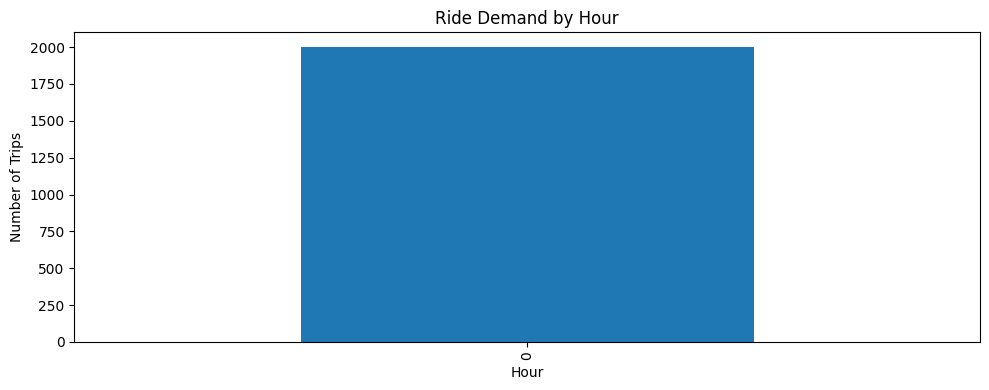

In [17]:
plt.figure(figsize=(10, 4))
trips.groupby('hour')['trip_id'].count().plot(kind='bar')
plt.title('Ride Demand by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Trips')
plt.tight_layout()
plt.savefig('ride_demand_by_hour.png')
plt.show()

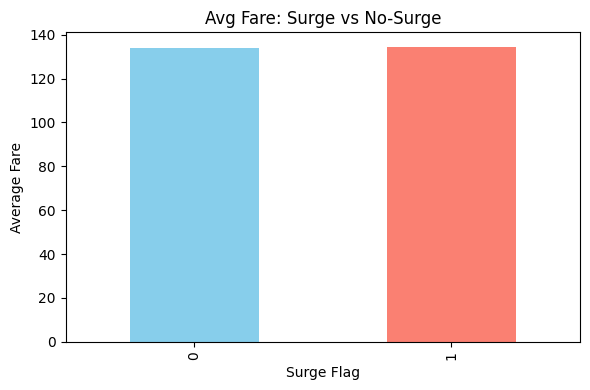

In [18]:
plt.figure(figsize=(6, 4))
trips.groupby('surge_flag')['fare_amount'].mean().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Avg Fare: Surge vs No-Surge')
plt.xlabel('Surge Flag')
plt.ylabel('Average Fare')
plt.tight_layout()
plt.savefig('surge_vs_nosurge.png')
plt.show()